In [43]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

In [44]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_FILE = Path(r"C:\Users\FadSaif\Documents\malaysia_sentiment_project\Data\processed\final_youtube_sentiment_825_balanced.csv")
df = pd.read_csv(DATA_FILE, encoding="utf-8-sig")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (825, 70)


,record_id,platform,content_type,comment_id,thread_id,video_id,video_title,channel_title,video_url,video_published_at,...,reviewed_at,review_decision_source,replacement_status,replacement_notes,supplement_reason,supplement_target_label,dataset_split_ready,final_dataset_name,final_dataset_created_at,final_dataset_sequence
0,YT_Ugysi_mCOp5GCdQrUlF4AaABAg,YouTube,top_level_comment,Ugysi_mCOp5GCdQrUlF4AaABAg,Ugysi_mCOp5GCdQrUlF4AaABAg,lWY3O9pFexo,KOS SARA HIDUP | PM Umum Butiran Penghargaan U...,Buletin TV3,https://www.youtube.com/watch?v=lWY3O9pFexo,2025-07-22T12:11:44Z,...,2026-06-18 18:58:29,human_manual_review,NaN,NaN,NaN,NaN,True,final_youtube_sentiment_825_balanced,2026-06-18 20:43:24,1
1,YT_UgyfIM6qYUIHjQoExA94AaABAg,YouTube,top_level_comment,UgyfIM6qYUIHjQoExA94AaABAg,UgyfIM6qYUIHjQoExA94AaABAg,mVmYibok-7A,[TERKINI] MOF sekat MyKad individu salah guna ...,Astro AWANI,https://www.youtube.com/watch?v=mVmYibok-7A,2026-03-23T23:22:33Z,...,2026-06-18 19:16:38,human_manual_review,NaN,NaN,NaN,NaN,True,final_youtube_sentiment_825_balanced,2026-06-18 20:43:24,2
2,YT_Ugwfo2MIFn9ZbR7WueJ4AaABAg,YouTube,top_level_comment,Ugwfo2MIFn9ZbR7WueJ4AaABAg,Ugwfo2MIFn9ZbR7WueJ4AaABAg,L-iPwc5b3oI,Malaysia rolls out the welcome mat for first t...,The Star,https://www.youtube.com/watch?v=L-iPwc5b3oI,2026-01-01T05:54:35Z,...,2026-06-18 15:52:41,human_manual_review,NaN,NaN,NaN,NaN,True,final_youtube_sentiment_825_balanced,2026-06-18 20:43:24,3
3,YT_UgzD8vvXykvFgAQuBLR4AaABAg,YouTube,top_level_comment,UgzD8vvXykvFgAQuBLR4AaABAg,UgzD8vvXykvFgAQuBLR4AaABAg,0zi0v_kJ7BE,Belanjawan 2026: Bantuan tunai STR dikurang RM...,KiniTV,https://www.youtube.com/watch?v=0zi0v_kJ7BE,2025-10-13T05:24:51Z,...,2026-06-18 18:30:45,human_manual_review,NaN,NaN,NaN,NaN,True,final_youtube_sentiment_825_balanced,2026-06-18 20:43:24,4
4,YT_Ugw67x7dxWu14CzSa8Z4AaABAg,YouTube,top_level_comment,Ugw67x7dxWu14CzSa8Z4AaABAg,Ugw67x7dxWu14CzSa8Z4AaABAg,mVmYibok-7A,[TERKINI] MOF sekat MyKad individu salah guna ...,Astro AWANI,https://www.youtube.com/watch?v=mVmYibok-7A,2026-03-23T23:22:33Z,...,2026-06-18 15:19:42,human_manual_review,NaN,NaN,NaN,NaN,True,final_youtube_sentiment_825_balanced,2026-06-18 20:43:24,5


**1. Dataset Quality Check**


In [46]:
required_columns = ["clean_text", "final_label"]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df.copy()

df["clean_text"] = df["clean_text"].fillna("").astype(str).str.strip()
df["final_label"] = df["final_label"].fillna("").astype(str).str.strip().str.lower()

valid_labels = ["negative", "neutral", "positive"]

df = df[df["final_label"].isin(valid_labels)]
df = df[df["clean_text"] != ""]

df = df.drop_duplicates(subset=["clean_text", "final_label"]).reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print(df["final_label"].value_counts())

Cleaned dataset shape: (825, 70)
final_label
positive    275
negative    275
neutral     275
Name: count, dtype: int64


**2. label distribution chart**

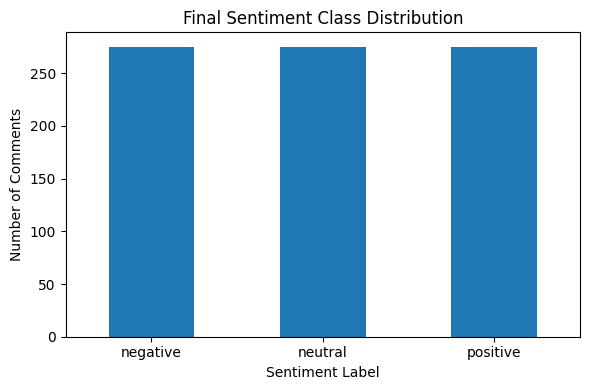

In [48]:
label_counts = df["final_label"].value_counts().reindex(valid_labels)

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Final Sentiment Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**3. train/test split**

In [50]:
X = df["clean_text"]
y = df["final_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training size:", len(X_train))
print("Testing size :", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training size: 660
Testing size : 165

Training distribution:
final_label
negative    220
positive    220
neutral     220
Name: count, dtype: int64

Testing distribution:
final_label
neutral     55
positive    55
negative    55
Name: count, dtype: int64


**4. evaluation helper**

In [52]:
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    result = {
        "model": model_name,
        "accuracy": accuracy,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted,
    }

    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print("Accuracy :", round(accuracy, 4))
    print("Macro F1 :", round(f1_macro, 4))
    print()
    print(classification_report(y_true, y_pred, labels=valid_labels, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=valid_labels)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(range(len(valid_labels)), valid_labels, rotation=45)
    plt.yticks(range(len(valid_labels)), valid_labels)

    for i in range(len(valid_labels)):
        for j in range(len(valid_labels)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

    return result

**5. Model 1: Logistic Regression baseline**

TF-IDF + Logistic Regression
Accuracy : 0.4727
Macro F1 : 0.4732

              precision    recall  f1-score   support

    negative       0.51      0.53      0.52        55
     neutral       0.41      0.45      0.43        55
    positive       0.51      0.44      0.47        55

    accuracy                           0.47       165
   macro avg       0.48      0.47      0.47       165
weighted avg       0.48      0.47      0.47       165



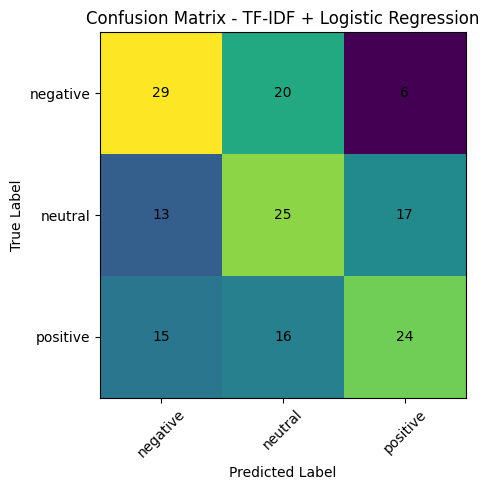

In [54]:
logreg_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

logreg_model.fit(X_train, y_train)

logreg_predictions = logreg_model.predict(X_test)

logreg_result = evaluate_model(
    "TF-IDF + Logistic Regression",
    y_test,
    logreg_predictions,
)

**6. Model 2: Linear SVM**

TF-IDF + Linear SVM
Accuracy : 0.4545
Macro F1 : 0.4551

              precision    recall  f1-score   support

    negative       0.52      0.51      0.51        55
     neutral       0.39      0.40      0.39        55
    positive       0.46      0.45      0.46        55

    accuracy                           0.45       165
   macro avg       0.46      0.45      0.46       165
weighted avg       0.46      0.45      0.46       165



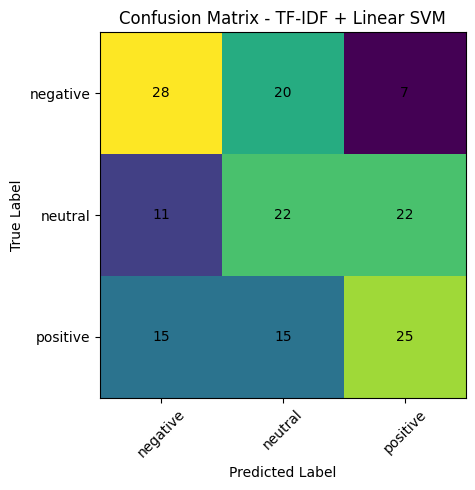

In [56]:
svm_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
            ),
        ),
        (
            "classifier",
            LinearSVC(
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

svm_result = evaluate_model(
    "TF-IDF + Linear SVM",
    y_test,
    svm_predictions,
)

**7. Model 3: XLM-RoBERTa direct evaluation**

In [58]:
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment-multilingual"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
xlmr_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
xlmr_model.to(device)
xlmr_model.eval()

id2label = xlmr_model.config.id2label

print(id2label)

Device: cpu


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{0: 'negative', 1: 'neutral', 2: 'positive'}


**8. XLM-RoBERTa prediction function**

In [60]:
def normalize_transformer_label(raw_label, label_id):
    label = str(raw_label).lower().strip()

    mapping = {
        "negative": "negative",
        "neutral": "neutral",
        "positive": "positive",
        "label_0": "negative",
        "label_1": "neutral",
        "label_2": "positive",
    }

    if label in mapping:
        return mapping[label]

    fallback = {
        0: "negative",
        1: "neutral",
        2: "positive",
    }

    return fallback[label_id]


def predict_xlmr(texts, batch_size=16, max_length=128):
    predictions = []

    texts = list(texts)

    with torch.no_grad():
        for start in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[start:start + batch_size]

            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            )

            encoded = {key: value.to(device) for key, value in encoded.items()}

            outputs = xlmr_model(**encoded)
            probabilities = torch.softmax(outputs.logits, dim=-1)

            predicted_ids = torch.argmax(probabilities, dim=-1).detach().cpu().numpy()

            for predicted_id in predicted_ids:
                raw_label = id2label.get(int(predicted_id), f"LABEL_{predicted_id}")
                normalized_label = normalize_transformer_label(raw_label, int(predicted_id))
                predictions.append(normalized_label)

    return predictions

**9.evaluate XLM-RoBERTa**

100%|██████████████████████████████████████████████████████████████████████████████████| 11/11 [00:12<00:00,  1.14s/it]

Pretrained XLM-RoBERTa Sentiment
Accuracy : 0.5939
Macro F1 : 0.5845

              precision    recall  f1-score   support

    negative       0.62      0.56      0.59        55
     neutral       0.52      0.42      0.46        55
    positive       0.62      0.80      0.70        55

    accuracy                           0.59       165
   macro avg       0.59      0.59      0.58       165
weighted avg       0.59      0.59      0.58       165



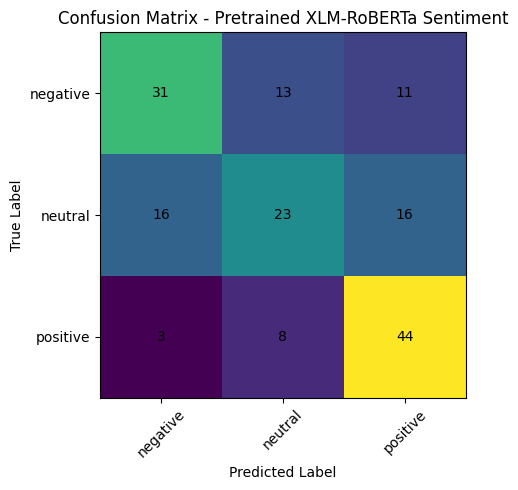

In [62]:
xlmr_predictions = predict_xlmr(X_test, batch_size=16)

xlmr_result = evaluate_model(
    "Pretrained XLM-RoBERTa Sentiment",
    y_test,
    xlmr_predictions,
)

In [63]:
from sklearn.pipeline import FeatureUnion

Word + Char TF-IDF + Logistic Regression
Accuracy : 0.5152
Macro F1 : 0.5165

              precision    recall  f1-score   support

    negative       0.56      0.53      0.54        55
     neutral       0.44      0.49      0.47        55
    positive       0.56      0.53      0.54        55

    accuracy                           0.52       165
   macro avg       0.52      0.52      0.52       165
weighted avg       0.52      0.52      0.52       165



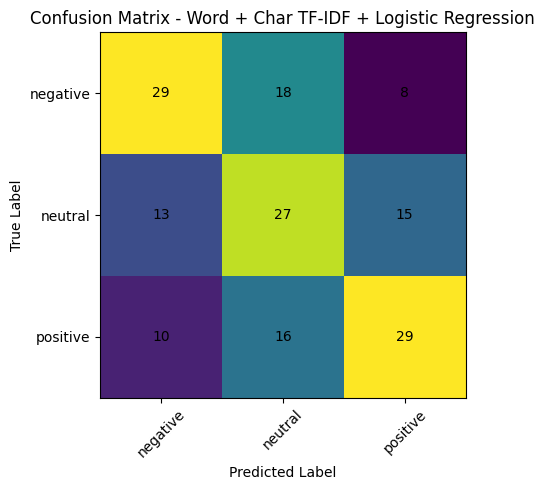

In [64]:
word_char_logreg_model = Pipeline(
    steps=[
        (
            "features",
            FeatureUnion(
                [
                    (
                        "word_tfidf",
                        TfidfVectorizer(
                            analyzer="word",
                            lowercase=True,
                            ngram_range=(1, 2),
                            min_df=2,
                            max_df=0.95,
                            sublinear_tf=True,
                        ),
                    ),
                    (
                        "char_tfidf",
                        TfidfVectorizer(
                            analyzer="char_wb",
                            lowercase=True,
                            ngram_range=(3, 5),
                            min_df=2,
                            max_df=0.95,
                            sublinear_tf=True,
                        ),
                    ),
                ]
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

word_char_logreg_model.fit(X_train, y_train)

word_char_logreg_predictions = word_char_logreg_model.predict(X_test)

word_char_logreg_result = evaluate_model(
    "Word + Char TF-IDF + Logistic Regression",
    y_test,
    word_char_logreg_predictions,
)

Word + Char TF-IDF + Linear SVM
Accuracy : 0.503
Macro F1 : 0.5038

              precision    recall  f1-score   support

    negative       0.58      0.56      0.57        55
     neutral       0.44      0.45      0.45        55
    positive       0.49      0.49      0.49        55

    accuracy                           0.50       165
   macro avg       0.50      0.50      0.50       165
weighted avg       0.50      0.50      0.50       165



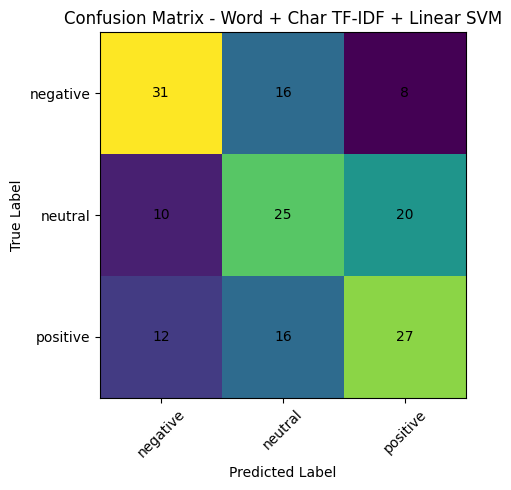

In [65]:
word_char_svm_model = Pipeline(
    steps=[
        (
            "features",
            FeatureUnion(
                [
                    (
                        "word_tfidf",
                        TfidfVectorizer(
                            analyzer="word",
                            lowercase=True,
                            ngram_range=(1, 2),
                            min_df=2,
                            max_df=0.95,
                            sublinear_tf=True,
                        ),
                    ),
                    (
                        "char_tfidf",
                        TfidfVectorizer(
                            analyzer="char_wb",
                            lowercase=True,
                            ngram_range=(3, 5),
                            min_df=2,
                            max_df=0.95,
                            sublinear_tf=True,
                        ),
                    ),
                ]
            ),
        ),
        (
            "classifier",
            LinearSVC(
                class_weight="balanced",
                random_state=42,
                max_iter=5000,
            ),
        ),
    ]
)

word_char_svm_model.fit(X_train, y_train)

word_char_svm_predictions = word_char_svm_model.predict(X_test)

word_char_svm_result = evaluate_model(
    "Word + Char TF-IDF + Linear SVM",
    y_test,
    word_char_svm_predictions,
)

**10 . Model Comparison**

In [67]:
results = pd.DataFrame(
    [
        logreg_result,
        svm_result,
        word_char_logreg_result,
        word_char_svm_result,
        xlmr_result,
    ]
)

results = results.sort_values(
    by="macro_f1",
    ascending=False,
).reset_index(drop=True)

results

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,Pretrained XLM-RoBERTa Sentiment,0.593939,0.587482,0.593939,0.584512,0.587482,0.593939,0.584512
1,Word + Char TF-IDF + Logistic Regression,0.515152,0.519336,0.515152,0.516543,0.519336,0.515152,0.516543
2,Word + Char TF-IDF + Linear SVM,0.503030,0.504804,0.503030,0.503804,0.504804,0.503030,0.503804
3,TF-IDF + Logistic Regression,0.472727,0.476415,0.472727,0.473160,0.476415,0.472727,0.473160
4,TF-IDF + Linear SVM,0.454545,0.455815,0.454545,0.455111,0.455815,0.454545,0.455111


**11.Model comparison chart**

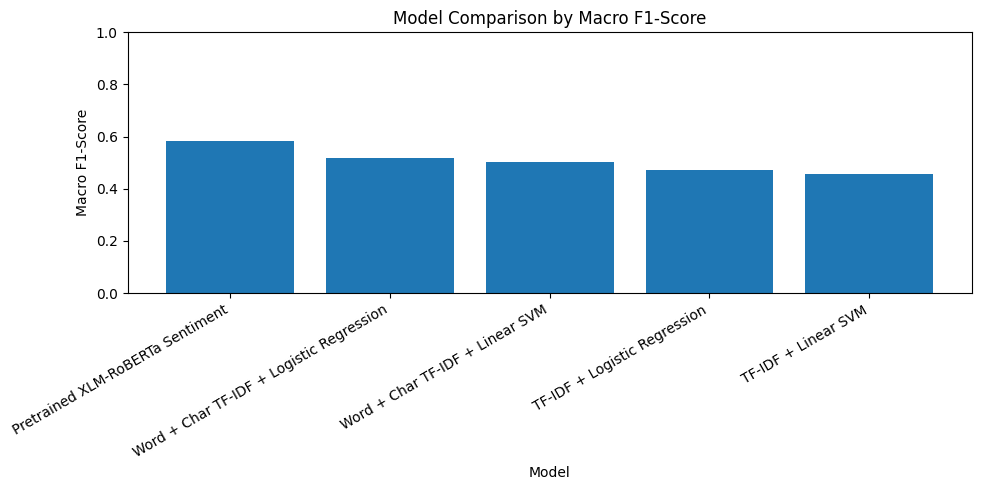

In [69]:
plt.figure(figsize=(10, 5))
plt.bar(results["model"], results["macro_f1"])
plt.title("Model Comparison by Macro F1-Score")
plt.xlabel("Model")
plt.ylabel("Macro F1-Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**12. Save results and best model**

In [89]:
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

results.to_csv(
    RESULTS_DIR / "model_comparison_results.csv",
    index=False,
    encoding="utf-8-sig",
)

best_model_name = results.iloc[0]["model"]

model_registry = {
    "TF-IDF + Logistic Regression": (
        logreg_model,
        "best_model_logistic_regression.joblib",
    ),
    "TF-IDF + Linear SVM": (
        svm_model,
        "best_model_linear_svm.joblib",
    ),
    "Word + Char TF-IDF + Logistic Regression": (
        word_char_logreg_model,
        "best_model_word_char_logistic_regression.joblib",
    ),
    "Word + Char TF-IDF + Linear SVM": (
        word_char_svm_model,
        "best_model_word_char_linear_svm.joblib",
    ),
}

if best_model_name in model_registry:
    best_model, best_model_filename = model_registry[best_model_name]

    joblib.dump(
        best_model,
        MODELS_DIR / best_model_filename,
    )

    print("Saved best trainable model:")
    print(MODELS_DIR / best_model_filename)

else:
    best_model_filename = None
    print("Best model is the pretrained XLM-RoBERTa model.")
    print("No joblib file saved because the transformer is loaded from Hugging Face.")

metadata = {
    "dataset": str(DATA_FILE),
    "train_size": len(X_train),
    "test_size": len(X_test),
    "labels": valid_labels,
    "best_model": best_model_name,
    "best_model_file": best_model_filename,
    "random_state": 42,
    "tested_models": results["model"].tolist(),
}

with open(RESULTS_DIR / "training_metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=4)

print("Saved results to:", RESULTS_DIR)

Best model is the pretrained XLM-RoBERTa model.
No joblib file saved because the transformer is loaded from Hugging Face.
Saved results to: C:\Users\FadSaif\results


In [91]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\FadSaif\Documents\malaysia_sentiment_project")

DATA_FILE = PROJECT_ROOT / "Data" / "processed" / "final_youtube_sentiment_825_balanced.csv"

MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_FILE)
print("Models folder:", MODELS_DIR)
print("Results folder:", RESULTS_DIR)

Project root: C:\Users\FadSaif\Documents\malaysia_sentiment_project
Dataset: C:\Users\FadSaif\Documents\malaysia_sentiment_project\Data\processed\final_youtube_sentiment_825_balanced.csv
Models folder: C:\Users\FadSaif\Documents\malaysia_sentiment_project\models
Results folder: C:\Users\FadSaif\Documents\malaysia_sentiment_project\results


In [93]:
import joblib
import json
from datetime import datetime

BEST_MODEL_FILE = MODELS_DIR / "best_model_word_char_logistic_regression.joblib"

joblib.dump(
    word_char_logreg_model,
    BEST_MODEL_FILE
)

metadata = {
    "model_name": "Word + Char TF-IDF + Logistic Regression",
    "model_file": str(BEST_MODEL_FILE),
    "dataset_file": str(DATA_FILE),
    "features": [
        "Word TF-IDF ngrams 1-2",
        "Character TF-IDF ngrams 3-5"
    ],
    "classifier": "Logistic Regression",
    "random_state": 42,
    "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

with open(RESULTS_DIR / "deployed_model_metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=4)

print("Model saved successfully:")
print(BEST_MODEL_FILE)

Model saved successfully:
C:\Users\FadSaif\Documents\malaysia_sentiment_project\models\best_model_word_char_logistic_regression.joblib


In [95]:
from pathlib import Path
import joblib

MODEL_FILE = Path(
    r"C:\Users\FadSaif\Documents\malaysia_sentiment_project\models\best_model_word_char_logistic_regression.joblib"
)

model = joblib.load(MODEL_FILE)

test_comments = [
    "Harga barang makin naik, rakyat makin susah.",
    "Bila program bantuan ni bermula?",
    "Bagus usaha kerajaan bantu rakyat."
]

for comment in test_comments:
    prediction = model.predict([comment])[0]
    print(comment, "=>", prediction)

Harga barang makin naik, rakyat makin susah. => negative
Bila program bantuan ni bermula? => positive
Bagus usaha kerajaan bantu rakyat. => negative
